In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from environment2 import MultiAssetTradingEnvForex
from stable_baselines3 import PPO

start = "2006-01-01"
end = "2022-12-31"
curr_date = "2025-07-01"

def download_data(tickers, start=start, end=end):
    data_dict = {}
    for ticker in tickers:
        df = yf.download(ticker, start=start, end=end)
        df = df[["Open", "High", "Low", "Close"]].dropna()
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
        all_weekdays = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')
        df_full = df.reindex(all_weekdays)
        df_filled = df_full.ffill()
        data_dict[ticker] = df_filled
    return data_dict

tickers = ["EUR=X", "JPY=X", "GBP=X", "CHF=X", "CAD=X"]
data_dict = download_data(tickers)

for key, df in data_dict.items():
    print(f"{key}")
    print(df.head())
    print(df.shape[0])
    print(df.isna().any(axis=1).sum())

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.

EUR=X
Price          Open     High      Low    Close
Ticker        EUR=X    EUR=X    EUR=X    EUR=X
2006-01-02  0.84445  0.84638  0.84282  0.84624
2006-01-03  0.84624  0.84624  0.83091  0.83105
2006-01-04  0.83119  0.83132  0.82359  0.82563
2006-01-05  0.82549  0.82836  0.82495  0.82597
2006-01-06  0.82610  0.82740  0.82142  0.82277
4435
0
JPY=X
Price             Open        High         Low       Close
Ticker           JPY=X       JPY=X       JPY=X       JPY=X
2006-01-02  117.870003  118.010002  117.540001  117.800003
2006-01-03  117.800003  117.860001  115.839996  115.980003
2006-01-04  116.010002  116.430000  115.610001  116.220001
2006-01-05  116.199997  116.440002  115.760002  116.000000
2006-01-06  116.000000  116.269997  114.230003  114.389999
4435
0
GBP=X
Price          Open     High      Low    Close
Ticker        GBP=X    GBP=X    GBP=X    GBP=X
2006-01-02  0.58082  0.58167  0.57964  0.58167
2006-01-03  0.58173  0.58173  0.57179  0.57189
2006-01-04  0.57218  0.57248  0.56783 

In [2]:
# Example usage functions
    # Example usage - Replace with your own data loading
    # Your data should be a dictionary like: {'AAPL': df1, 'MSFT': df2, 'GOOGL': df3}
    # where each DataFrame has columns: ['Open', 'High', 'Low', 'Close', 'Volume']
    
    # Example of how to use with your own data:
    # your_data = {
    #     'AAPL': pd.read_csv('aapl_data.csv'),
    #     'MSFT': pd.read_csv('msft_data.csv'),
    #     'GOOGL': pd.read_csv('googl_data.csv')
    # }
    
    # env = MultiAssetTradingEnv(
    #     data=your_data,
    #     initial_balance=100000,
    #     lookback_window=20
    # )
    
    # print("Environment class is ready. Load your OHLCV data and create the environment instance.")
    # print("Expected data format:")
    # print("data = {'ASSET1': DataFrame, 'ASSET2': DataFrame, ...}")
    # print("Each DataFrame should have columns: ['Open', 'High', 'Low', 'Close', 'Volume']")

In [3]:
from stable_baselines3.common.env_util import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

def make_env():
    env = MultiAssetTradingEnvForex(data_dict, initial_balance=1000, lookback_window=20, max_position_per_asset=0.5, buy_fraction=0.3, sell_fraction=0.5)
    return Monitor(env)

env = DummyVecEnv([make_env])  # Stable-Baselines3 expects vectorized envs
base_env = env.envs[0]

In [4]:
model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    ent_coef=0.01,  # entropy bonus to encourage exploration
    tensorboard_log="./ppo_trading_tensorboard/"
)

model.learn(total_timesteps=100_000)

Using cpu device
Logging to ./ppo_trading_tensorboard/PPO_31
-----------------------------
| time/              |      |
|    fps             | 240  |
|    iterations      | 1    |
|    time_elapsed    | 8    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 233         |
|    iterations           | 2           |
|    time_elapsed         | 17          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008583577 |
|    clip_fraction        | 0.106       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.49       |
|    explained_variance   | -0.0052     |
|    learning_rate        | 0.0003      |
|    loss                 | 1.71        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0113     |
|    value_loss           | 2.7         |
---------------

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2522630039.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2522630039.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2522630039.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2522630039.py:62: FutureWarning: YF.download() has changed argument auto_adjust default 

Initial Portfolio Value: $1,000.00
Final Portfolio Value: $429.47
Total Return: -57.05%
Max Portfolio Value: $1,040.86
Max Drawdown: 95.28%


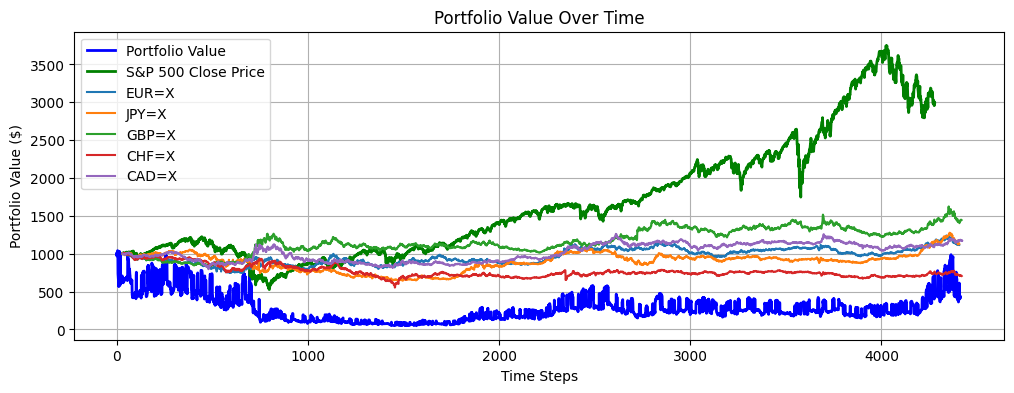

In [5]:
import matplotlib.pyplot as plt

def evaluate_policy(env, model, episodes=1):
    """Simple policy evaluation with key metrics and plots"""
    
    # Run episode
    obs, info = env.reset()
    portfolio_values = [info['portfolio_value']]
    actions_taken = []
    
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        portfolio_values.append(info['portfolio_value'])
        actions_taken.append(action)
        
        if terminated or truncated:
            break
    
    def max_drawdown(portfolio):
        """Calculate the maximum drawdown of a portfolio."""
        peak = portfolio[0]
        max_dd = 0
        for value in portfolio:
            if value > peak:
                peak = value
            dd = (peak - value) / peak
            if dd > max_dd:
                max_dd = dd
        return max_dd
    
    max_dd = max_drawdown(portfolio_values)

    # Calculate metrics
    initial_value = portfolio_values[0]
    final_value = portfolio_values[-1]
    total_return = (final_value - initial_value) / initial_value * 100
    max_value = max(portfolio_values)

    sp500 = yf.download("^GSPC", start=start, end=end)
    sp500_reset = sp500.reset_index()
    sp500_aligned = sp500_reset[30:]
    sp500_Close = sp500_aligned['Close'].dropna()

    # Normalize SP500 to start at $10,000
    normalized_sp500 = sp500_Close / sp500_Close.iloc[0] * 1000
    
    # Print results
    print(f"Initial Portfolio Value: ${initial_value:,.2f}")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2f}%")
    print(f"Max Portfolio Value: ${max_value:,.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    
    # Plot portfolio value
    plt.figure(figsize=(12, 4))
    plt.plot(portfolio_values, linewidth=2, color="blue", label="Portfolio Value")
    plt.plot(normalized_sp500, linewidth=2, color="green", label="S&P 500 Close Price")

    for tick in tickers:
        tick_data = yf.download(tick, start=start, end=end)
        tick_data_reset = tick_data.reset_index()
        tick_data_aligned = tick_data_reset[30:]
        tick_data_close = tick_data_aligned['Close'].dropna()

        # Normalize SP500 to start at $10,000
        normalized_tick_data = tick_data_close / tick_data_close.iloc[0] * 1000
        plt.plot(normalized_tick_data, label=tick)

    plt.title('Portfolio Value Over Time')
    plt.xlabel('Time Steps')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {
        'portfolio_values': portfolio_values,
        'total_return': total_return,
        'final_value': final_value,
        'max_drawdown': max_dd
    }

# Usage in your notebook:
results = evaluate_policy(base_env, model)

In [6]:
obs = env.reset()
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _ = env.step(action)
    env.envs[0].render()

Step: 1
Portfolio Value: $970.28
Cash: $970.28
Margin Used: $0.00
Buying Power: $9,702.81
Leverage Ratio: 0.00x
EUR=X: 0.0000 shares (NONE) @ $0.82 | Value: $0.00 | P&L: $0.00
JPY=X: 0.0000 shares (NONE) @ $117.31 | Value: $0.00 | P&L: $0.00
GBP=X: 0.0000 shares (NONE) @ $0.56 | Value: $0.00 | P&L: $0.00
CHF=X: 0.0000 shares (NONE) @ $1.28 | Value: $0.00 | P&L: $0.00
CAD=X: 0.0000 shares (NONE) @ $1.14 | Value: $0.00 | P&L: $0.00
----------------------------------------------------------------------
Step: 2
Portfolio Value: $995.04
Cash: $995.04
Margin Used: $0.00
Buying Power: $9,950.45
Leverage Ratio: 0.00x
EUR=X: 0.0000 shares (NONE) @ $0.83 | Value: $0.00 | P&L: $0.00
JPY=X: 0.0000 shares (NONE) @ $117.97 | Value: $0.00 | P&L: $0.00
GBP=X: 0.0000 shares (NONE) @ $0.56 | Value: $0.00 | P&L: $0.00
CHF=X: 0.0000 shares (NONE) @ $1.29 | Value: $0.00 | P&L: $0.00
CAD=X: 0.0000 shares (NONE) @ $1.14 | Value: $0.00 | P&L: $0.00
-------------------------------------------------------------

In [7]:
model.save("trading_bot_forex")

In [8]:
forward_data_dict = download_data(tickers, start=end, end=curr_date)
forward_env = MultiAssetTradingEnvForex(
    data=forward_data_dict,
    initial_balance=1000,
    lookback_window=20,
    normalize_observations=True,
    max_position_per_asset=0.5,
    buy_fraction=0.3,
    sell_fraction=0.5
)

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/371070991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.

In [9]:
def simple_forward_test(model, env):
    """
    Simple forward testing - just run the model and get basic results
    """
    # Reset environment
    obs, info = env.reset()
    
    portfolio_values = [info['portfolio_value']]
    
    # Run through all steps
    done = False
    while not done:
        # Get action from model
        action, _ = model.predict(obs, deterministic=True)
        
        # Take step
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Store portfolio value
        portfolio_values.append(info['portfolio_value'])

    plt.figure(figsize=(12, 6))
    for tick in tickers:
        tick_data = yf.download(tick, start=end, end=curr_date)
        tick_data_reset = tick_data.reset_index()
        tick_data_aligned = tick_data_reset[30:]
        tick_data_close = tick_data_aligned['Close'].dropna()

        # Normalize SP500 to start at $10,000
        normalized_tick_data = tick_data_close / tick_data_close.iloc[0] * 1000
        plt.plot(normalized_tick_data, label=tick)
    
    # Calculate results
    initial_value = env.initial_balance
    final_value = portfolio_values[-1]
    total_return = ((final_value / initial_value) - 1) * 100
    
    # Plot results
    plt.plot(portfolio_values, linewidth=2, color='blue')
    plt.axhline(y=initial_value, color='red', linestyle='--', alpha=0.7, label=f'Initial: ${initial_value:,.0f}')
    plt.title('Forward Testing Results')
    plt.xlabel('Days')
    plt.ylabel('Portfolio Value ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print results
    print(f"Initial Portfolio Value: ${initial_value:,.2f}")
    print(f"Final Portfolio Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2f}%")
    
    return {
        'initial_value': initial_value,
        'final_value': final_value,
        'total_return': total_return,
        'portfolio_values': portfolio_values
    }

/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tick_data = yf.download(tick, start=end, end=curr_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/yq/8mnn7kqs5q1bg63wmxd9mjjw0000gn/T/ipykernel_3784/2629827705.py:25: FutureWarning: YF.download() has changed argument auto_ad

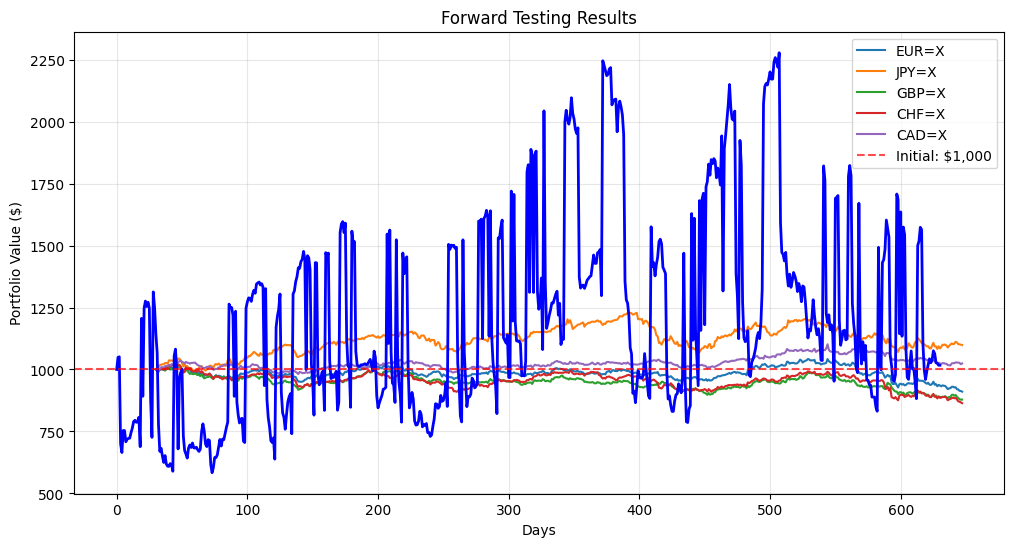

Initial Portfolio Value: $1,000.00
Final Portfolio Value: $1,017.00
Total Return: 1.70%


In [10]:
results = simple_forward_test(model, forward_env)

In [11]:
obs, info = forward_env.reset()

# Run through all steps
done = False
while not done:
    # Get action from model
    action, _ = model.predict(obs, deterministic=True)
    
    # Take step
    obs, reward, terminated, truncated, info = forward_env.step(action)
    done = terminated or truncated
    # Render environment
    forward_env.render()

Step: 1
Portfolio Value: $1,048.35
Cash: $1,048.35
Margin Used: $0.00
Buying Power: $10,483.50
Leverage Ratio: 0.00x
EUR=X: 0.0000 shares (NONE) @ $0.92 | Value: $0.00 | P&L: $0.00
JPY=X: 0.0000 shares (NONE) @ $130.48 | Value: $0.00 | P&L: $0.00
GBP=X: 0.0000 shares (NONE) @ $0.81 | Value: $0.00 | P&L: $0.00
CHF=X: 0.0000 shares (NONE) @ $0.93 | Value: $0.00 | P&L: $0.00
CAD=X: 0.0000 shares (NONE) @ $1.34 | Value: $0.00 | P&L: $0.00
----------------------------------------------------------------------
Step: 2
Portfolio Value: $1,051.13
Cash: $1,051.13
Margin Used: $0.00
Buying Power: $10,511.31
Leverage Ratio: 0.00x
EUR=X: 0.0000 shares (NONE) @ $0.92 | Value: $0.00 | P&L: $0.00
JPY=X: 0.0000 shares (NONE) @ $130.11 | Value: $0.00 | P&L: $0.00
GBP=X: 0.0000 shares (NONE) @ $0.81 | Value: $0.00 | P&L: $0.00
CHF=X: 0.0000 shares (NONE) @ $0.92 | Value: $0.00 | P&L: $0.00
CAD=X: 0.0000 shares (NONE) @ $1.33 | Value: $0.00 | P&L: $0.00
---------------------------------------------------